# (Homework) Week 6 - DataScience Bootcamp Fall 2025

All solution cells are replaced with `# TODO` placeholders so you can fill them in.

**Name:** Meenakshi Madhu\
**Email:** mm14029@nyu.edu

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

### Problem 1: Dataset Splitting

1. You have recordings of 44 phones from 100 people; each person records ~200 phones/day for 5 days.
   - Design a valid training/validation/test split strategy that ensures the model generalizes to **new speakers**.

2. You now receive an additional dataset of 10,000 phone recordings from **Kilian**, a single speaker.
   - You must train a model that performs well **specifically for Kilian**, while also maintaining generalization.

*Describe your proposed split strategy and reasoning.* (Theory)

#### Ans 1.
Number of people = 100 <br/>
Number of phones = 44 <br>
Total number of recordings = number of people x rate of recordings x 5 days <br>
                           = 100 * 200 * 5 <br>
                           = 100,000 recordings <br>

We can split these 100,000 recordings as: <br>
Training:   70 speakers  (70,000 recordings) <br>
Validation: 15 speakers  (15,000 recordings) <br>
Test:       15 speakers  (15,000 recordings) <br>

<br>
The task is to design a valid split strategy to make the model work for "new speakers". <br>
To make sure this works as expected, we split the speakers into categories instead of the recordings. <br>
Ensuring that there is no speaker-overlap between the train, test, and validation datasets, we can expect the model to generalize to new speakers after training. <br>

#### Ans 2.
Objective is speaker-specific adaptation (for Kilian) and also to maintain generalization. <br>
We can use a multi-step split strategy:<br>

Split 1 - General Speaker Data (before adding Kilian) <br>
General Train: 70 speakers (approx 70,000 recordings) <br>
General Val:   15 speakers (approx 15,000 recordings) <br>
General Test:  15 speakers (approx 15,000 recordings) <br>

Split 2: Kilian-Specific Data <br>
Kilian Train: 7,000 recordings (70%) <br>
Kilian Val:   1,500 recordings (15%)<br>
Kilian Test:  1,500 recordings (15%)<br>


For training, use a multi-step strategy again:<br>
Stage 1: Base Model Training<br>
- Train on general speaker training set (70 speakers)<br>
- Learn speaker-independent phone representations<br>
- Validate on general validation set<br>

Stage 2: Mixed Fine-Tuning<br>
- Fine-tune on combined dataset: General train + Kilian train<br>
- Use weighted sampling or curriculum learning:<br>
    - Option A: Oversample Kilian data (2:1 or 3:1 ratio)<br>
    - Option B: Train in phases with increasing Kilian proportion<br>
- Dual validation: Track performance on both Kilian val + general val<br>

Stage 3: Evaluation<br>
- Kilian test set: Measures specialist performance<br>
- General test set: Ensures no catastrophic forgetting<br>
- Combined metric: Weighted average (e.g., 60% Kilian, 40% general)<br>

### Problem 2: K-Nearest Neighbors

1. **1-NN Classification:** Given dataset:

   Positive: (1,2), (1,4), (5,4)

   Negative: (3,1), (3,2)

   Plot the 1-NN decision boundary and classify new points visually.

2. **Feature Scaling:** Consider dataset:

   Positive: (100,2), (100,4), (500,4)

   Negative: (300,1), (300,2)

   What would the 1-NN classify point (500,1) as **before and after scaling** to [0,1] per feature?

3. **Handling Missing Values:** How can you modify K-NN to handle missing features in a test point?

4. **High-dimensional Data:** Why can K-NN still work well for images even with thousands of pixels?


#### Ans 1.

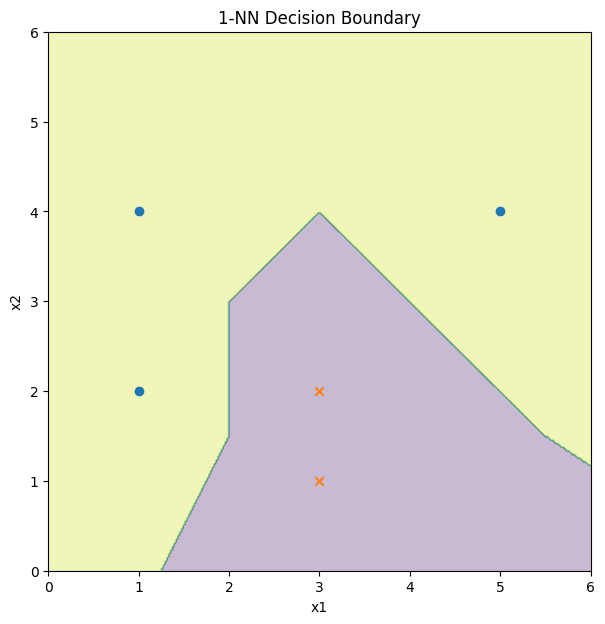

In [2]:
# Dataset
X_pos = np.array([[1,2],[1,4],[5,4]])
X_neg = np.array([[3,1],[3,2]])

X = np.vstack([X_pos, X_neg])
y = np.array([1,1,1,0,0])  # 1 = positive, 0 = negative

# 1-NN classifier
clf = KNeighborsClassifier(n_neighbors=1)
clf.fit(X, y)

# Create mesh grid
xx, yy = np.meshgrid(np.linspace(0,6,300), np.linspace(0,6,300))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = clf.predict(grid).reshape(xx.shape)

# Plot
plt.figure(figsize=(7,7))
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_pos[:,0], X_pos[:,1], marker='o')
plt.scatter(X_neg[:,0], X_neg[:,1], marker='x')
plt.title("1-NN Decision Boundary")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()


#### Ans 2.

##### Before Feature Scaling: <br>

Distances are dominated by the x-axis because values range from 100–500. <br>
The nearest point to (500,1) is:<br>

(500,4) -> **Positive** <br>

**Prediction: Positive**

##### After Min–Max Scaling to [0,1] per feature: <br>

After scaling, both features contribute proportionally: <br>

Scaled x-values: <br>
100 -> 0 <br>
300 -> 0.5 <br>
500 -> 1 <br>

Scaled y-values: <br>
1 -> 0 <br>
2 -> 0.333<br>
4 -> 1<br>

Nearest neighbor to scaled (500,1) = (1,0): <br>

Distances:<br>
To (500,4) -> farther<br>
To (300,1) -> becomes much closer after scaling -> Negative<br>

**Prediction: Negative (0)**

#### Ans 3.

1. Most common method is to Impute Missing Values. <br>
    Before running K-NN:

    **Simple imputations**:<br>
    Replace missing values with mean/median/mode of that feature.<br>

    **Better imputations:** <br>
    Use k-nearest neighbors imputation (KNN-Imputer)<br>
    Find nearest neighbors using available features.<br>
    Fill missing values using the neighbors’ feature values.

2. Distance Computation Using Only Common (Non-Missing) Features <br>
When calculating the distance between the test point and training points, ignore the dimensions where the test point has missing values. This means the distance calculation will only consider the features that are present in both the test point and the training point. For example, in Euclidean distance, the squared difference for missing features would be excluded from the sum.


3. Probabilistic / Model-Based Fill-in <br>
    If occurrences of missing values are structured:<br>
    Use a model (Gaussian, Regression, Autoencoder, etc.) to estimate the missing value distribution. <br>
    Compute expected distances under that distribution.

#### Ans 4.

Images have a special structure that makes K-NN more effective than expected.<br>
1. Image data lies on a low-dimensional manifold, even though raw pixel space is high-dimensional.

2. Images have strong local structure and pixel correlations, so Euclidean distances remain meaningful.

3. Images form clear local neighborhoods where visually similar images cluster together.
4. Large datasets provide dense coverage of each class, so a test image usually has a close neighbor from the correct class.

5. Dimensionality reduction or learned embeddings (PCA, autoencoders, CNN features) can further improve K-NN, but images often work well even without them.

### Problem 3: Part 1

You are given a fully trained Perceptron model with weight vector **w**, along with training set **D_TR** and test set **D_TE**.

1. Your co-worker suggests evaluating $h(x) = sign(w \cdot x)$ for every $(x, y)$ in D_TR and D_TE. Does this help determine whether test error is higher than training error?
2. Why is there no need to compute training error explicitly for the Perceptron algorithm?

1. Yes. <br>
Computing predictions h(x) on both datasets allows you to compute:

- Training error = fraction of training examples misclassified
- Test error = fraction of test examples misclassified

    Comparing these two quantities directly tells you whether the test error is higher.<br>
    So evaluating h(x) on both datasets does let you determine which error is larger.

2. The Perceptron makes zero training error on any linearly separable dataset. It updates weights only when it misclassifies a training point. When the algorithm converges, it reaches a state where no training point is misclassified.

    Hence, after convergence, training error = 0 automatically. <br>
    There is no need to compute it explicitly.<br>
    Even if the dataset is not perfectly separable, the training error is not what the Perceptron optimizes. It only updates on mistakes until it stops improving.

### Problem 3: Two-point 2D Dataset (Part 2)

Run the Perceptron algorithm **by hand or in code** on the following data:

1. Positive class: (10, -2)
2. Negative class: (12, 2)

Start with $w_0 = (0, 0)$ and a learning rate of 1.

- Compute how many updates are required until convergence.
- Write down the sequence of $w_i$ vectors.

In [3]:
# Data
X = np.array([[10, -2],  # positive
              [12,  2]]) # negative
y = np.array([1, -1])

# Parameters
w = np.array([0., 0.])
eta = 1.0

weights = [w.copy()]
updates = 0

max_epochs = 100
converged = False

for epoch in range(max_epochs):
    errors = 0
    for xi, yi in zip(X, y):
        if yi * np.dot(w, xi) <= 0:
            w = w + eta * yi * xi
            weights.append(w.copy())
            updates += 1
            errors += 1
    if errors == 0:
        converged = True
        break

print("Number of updates req until convergence: ",updates)
print("Weights:", weights)


Number of updates req until convergence:  9
Weights: [array([0., 0.]), array([10., -2.]), array([-2., -4.]), array([ 8., -6.]), array([-4., -8.]), array([  6., -10.]), array([ -6., -12.]), array([  4., -14.]), array([ -8., -16.]), array([  2., -18.])]


### Problem 4: Reconstructing the Weight Vector

Given the log of Perceptron updates:

| x | y | count |
|---|---|--------|
| (0, 0, 0, 0, 4) | +1 | 2 |
| (0, 0, 6, 5, 0) | +1 | 1 |
| (3, 0, 0, 0, 0) | -1 | 1 |
| (0, 9, 3, 6, 0) | -1 | 1 |
| (0, 1, 0, 2, 5) | -1 | 1 |

Assume learning rate = 1 and initial weight $w_0 = (0, 0, 0, 0, 0)$.

Compute the final weight vector after all updates.

#### Ans. 
We use the Perceptron update rule: <br>
w = w+ eta * yx <br>

The log gives how many times each (x, y) caused an update.<br>
With learning rate eta = 1 and w0 =(0,0,0,0,0), <br>

Final weight is:<br>

= w0 +2.(+1).(0,0,0,0,4)<br>
+1.(+1).(0,0,6,5,0)<br>
+1.(−1).(3,0,0,0,0)<br>
+1.(−1).(0,9,3,6,0)<br>
+1.(−1).(0,1,0,2,5)<br>
=(−3,−10,3,−3,3).<br>

So the final weight vector after all updates is: <br>
w=(−3,−10,3,−3,3)

### Problem 5: Visualizing Perceptron Convergence

Implement a Perceptron on a small 2D dataset with positive and negative examples.

- Plot the data points.
- After each update, visualize the decision boundary.
- Show how it converges to a stable separator.

In [4]:
# Perceptron implementation
# y = mx + c -> y = wx + b
class Perceptron:
    def __init__(self):
        self.w = None
        self.b = 0
        self.history = []

    def predict(self, x):
        return np.sign(np.dot(self.w, x) + self.b)

    def train_step(self, x, y):
        if self.w is None:
            self.w = np.zeros(len(x))

        pred = self.predict(x)

        # Save BEFORE update
        self.history.append((self.w.copy(), self.b))

        if pred != y:
            self.w += y * x
            self.b += y
            return False
        return True

In [5]:
X_pos = np.array([[3, 3],
                  [4, 3],
                  [3.5, 2.5]])
y_pos = np.ones(3)

X_neg = np.array([[1, 1],
                  [1.5, 2],
                  [2, 1]])
y_neg = -np.ones(3)

X_perceptron = np.vstack([X_pos, X_neg])
y_perceptron = np.concatenate([y_pos, y_neg])

In [6]:
# Train perceptron and visualize
perceptron = Perceptron()

print("Training Perceptron...\n")
print("="*60)

max_epochs = 20
for epoch in range(max_epochs):
    errors = 0
    for i, (x, y) in enumerate(zip(X_perceptron, y_perceptron)):
        correct = perceptron.train_step(x, y)
        if not correct:
            errors += 1
    
    print(f"Epoch {epoch + 1}: {errors} errors, w={perceptron.w}, b={perceptron.b:.2f}")
    
    if errors == 0:
        print(f"\nConverged after {epoch + 1} epochs!")
        break

print("="*60)

Training Perceptron...

Epoch 1: 4 errors, w=[-1.5 -1. ], b=-2.00
Epoch 2: 3 errors, w=[-1. -1.], b=-3.00
Epoch 3: 3 errors, w=[-0.5 -1. ], b=-4.00
Epoch 4: 3 errors, w=[ 0. -1.], b=-5.00
Epoch 5: 3 errors, w=[ 0.5 -1. ], b=-6.00
Epoch 6: 3 errors, w=[0.5 0. ], b=-7.00
Epoch 7: 3 errors, w=[1. 0.], b=-8.00
Epoch 8: 3 errors, w=[1.5 0. ], b=-9.00
Epoch 9: 2 errors, w=[3. 1.], b=-9.00
Epoch 10: 0 errors, w=[3. 1.], b=-9.00

Converged after 10 epochs!


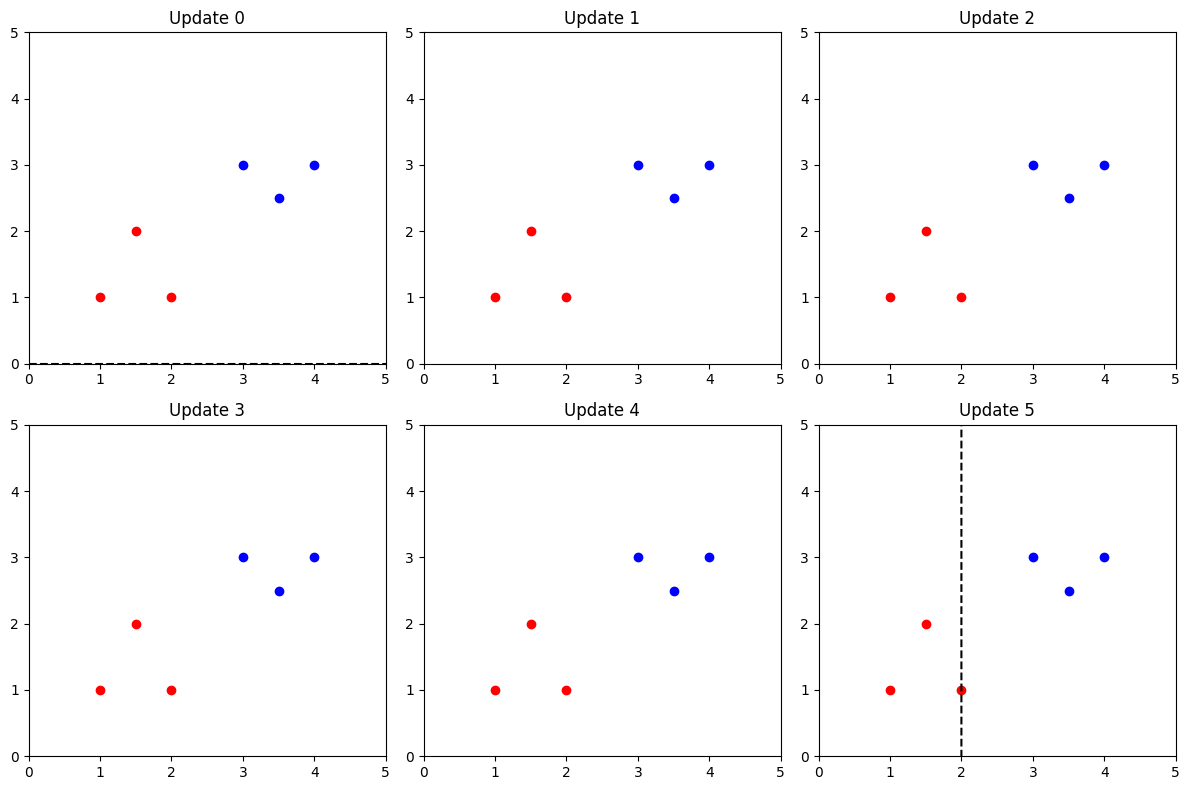

([4, 3, 3, 3, 3, 3, 3, 3, 2, 0], array([3., 1.]), np.float64(-9.0))

In [7]:
perceptron = Perceptron()

max_epochs = 20
epoch_errors = []

for epoch in range(max_epochs):
    errors = 0
    for x, y in zip(X_perceptron, y_perceptron):
        correct = perceptron.train_step(x, y)
        if not correct:
            errors += 1
    epoch_errors.append(errors)
    if errors == 0:
        break


#  Plot decision boundary after each epoch

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

def plot_boundary(ax, w, b):
    xx = np.linspace(0, 5, 100)
    yy = -(w[0]*xx + b) / (w[1] + 1e-6)
    ax.plot(xx, yy, 'k--', linewidth=1.5)

plot_i = 0
for (w, b) in perceptron.history[:6]:  # show first 6 updates
    ax = axes[plot_i]
    ax.scatter(X_pos[:,0], X_pos[:,1], c='blue', label='pos')
    ax.scatter(X_neg[:,0], X_neg[:,1], c='red', label='neg')
    plot_boundary(ax, w, b)
    ax.set_title(f"Update {plot_i}")
    ax.set_xlim(0,5)
    ax.set_ylim(0,5)
    plot_i += 1

plt.tight_layout()
plt.show()

(epoch_errors, perceptron.w, perceptron.b)
